# 05 — XGB vs DCC-GARCH: Deep Dive

Детальный анализ главного вывода диплома.

**Требуется**: `main.py` + ноутбук 04

In [1]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from thesis_app.notebook_helpers import apply_thesis_plot_style, preferred_xgb_label, best_ml_model_name, significance_stars, interpretation_text
apply_thesis_plot_style()


## Interpretation focus
This notebook is the benchmark showdown between a machine-learning model and the econometric baseline. Emphasize where ML adds practical value and where DCC remains competitive.

In [2]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import sys, os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from thesis_app.pipeline import load_config, build_paths, diebold_mariano, inv_fisher_z

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

cfg   = load_config(os.path.join(ROOT, 'config.yaml'))
paths = build_paths(ROOT)

csv_files = sorted(glob(os.path.join(paths.predictions, '*_predictions.csv')))
experiments = {os.path.basename(f).replace('_predictions.csv', ''):
               pd.read_csv(f, index_col=0, parse_dates=True) for f in csv_files}

# Load metrics to determine the best ML model (lowest avg RMSE, excl. baselines)
metrics_df = pd.read_csv(os.path.join(paths.results, 'metrics.csv'))
best_ml_col = best_ml_model_name(metrics_df)  # e.g. 'Ridge'
print(f'Loaded {len(experiments)} experiments')
print(f'Best ML model (by avg RMSE): {best_ml_col}')


Loaded 24 experiments
Best ML model (by avg RMSE): Ridge


In [3]:
# ── Полная таблица RMSE: XGB vs DCC ──────────────────────────────
rows = []
for exp_key, df in experiments.items():
    y = df['y_true'].dropna()
    xgb_col = preferred_xgb_label(df.columns)
    for model in df.columns:
        if model == 'y_true':
            continue
        pred = df[model].dropna()
        common = y.index.intersection(pred.index)
        if len(common) < 50:
            continue
        yt = y.loc[common].values
        yp = pred.loc[common].values
        label = 'XGB' if model in ('XGB_GPU', 'XGB_CPU') else model
        rows.append({'experiment': exp_key, 'model': label,
                     'RMSE': np.sqrt(mean_squared_error(yt, yp)),
                     'MAE': mean_absolute_error(yt, yp),
                     'R2': r2_score(yt, yp), 'n': len(common)})

full_df = pd.DataFrame(rows)

if 'XGB' in full_df['model'].unique() and 'DCC_GARCH' in full_df['model'].unique():
    comparison = full_df[full_df['model'].isin(['XGB','DCC_GARCH','Naive_Last'])].pivot_table(
        index='experiment', columns='model', values='RMSE')
    if 'XGB' in comparison.columns and 'DCC_GARCH' in comparison.columns:
        comparison['ratio_DCC_XGB'] = comparison['DCC_GARCH'] / comparison['XGB']
        comparison['XGB_better'] = comparison['XGB'] < comparison['DCC_GARCH']
        print(comparison.round(4).to_string())
        n = comparison['XGB_better'].sum()
        print(f'\nXGB better: {n}/{len(comparison)}, mean DCC/XGB ratio: {comparison["ratio_DCC_XGB"].mean():.2f}x')
else:
    print('DCC или XGB predictions не найдены. Запустите main.py.')
    print('Доступные модели:', list(full_df['model'].unique()))


model                              DCC_GARCH  Naive_Last     XGB  ratio_DCC_XGB  XGB_better
experiment                                                                                 
corr_BTC-USD_ETH-USD_w14_fisher_z     0.3280      0.1574  0.2157         1.5202        True
corr_BTC-USD_ETH-USD_w30_fisher_z     0.2136      0.0709  0.1183         1.8049        True
corr_BTC-USD_ETH-USD_w60_fisher_z     0.2024      0.0359  0.0614         3.2953        True
corr_BTC-USD_ETH-USD_w90_fisher_z     0.1866      0.0251  0.0486         3.8433        True
corr_BTC-USD_GLD_w14_fisher_z         0.3355      0.1439  0.2026         1.6558        True
corr_BTC-USD_GLD_w30_fisher_z         0.2169      0.0665  0.0998         2.1743        True
corr_BTC-USD_GLD_w60_fisher_z         0.1428      0.0343  0.0544         2.6246        True
corr_BTC-USD_GLD_w90_fisher_z         0.1229      0.0231  0.0390         3.1519        True
corr_BTC-USD_SLV_w14_fisher_z         0.3740      0.1443  0.2068         1.8085 

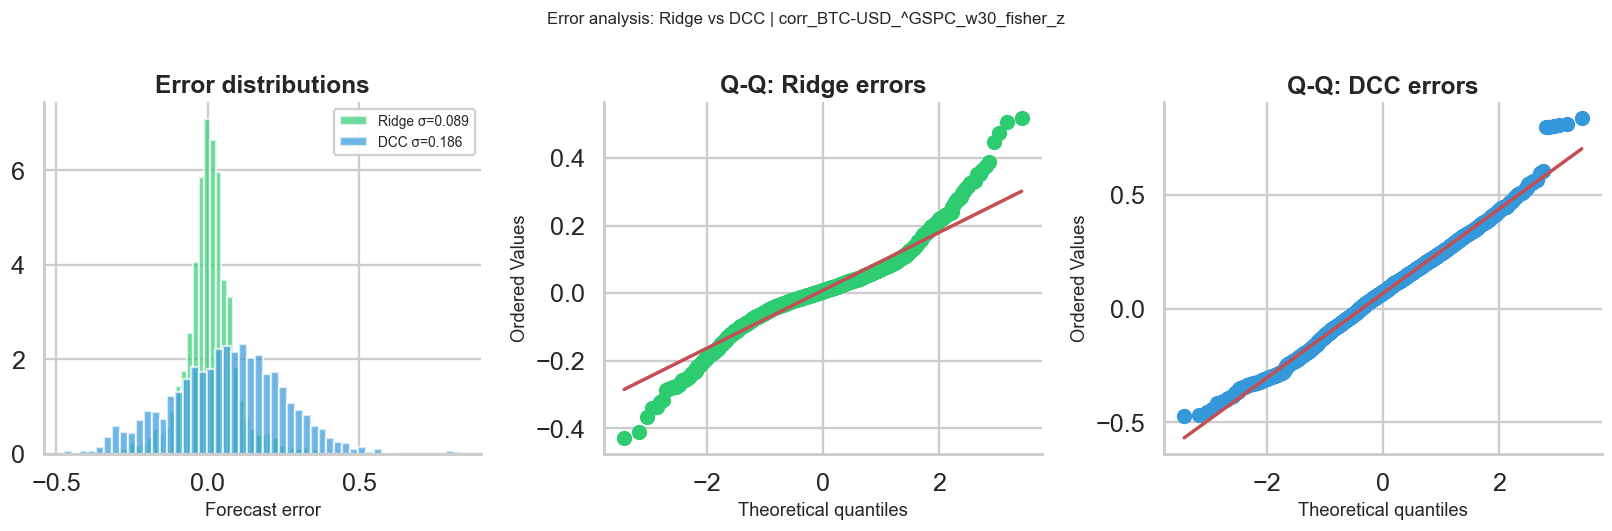

In [4]:
# ── Error distributions: best ML vs DCC ──────────────────────────────────────
KEY = 'corr_BTC-USD_^GSPC_w30_fisher_z'
if KEY not in experiments:
    KEY = list(experiments.keys())[0]
    print(f'Using: {KEY}')

df = experiments[KEY]
y  = df['y_true']

# Use best ML model (Ridge); fall back to XGB if Ridge is not present
ml_col   = best_ml_col if (best_ml_col and best_ml_col in df.columns) else preferred_xgb_label(df.columns)
ml_label = ml_col if ml_col else 'ML'

if ml_col and 'DCC_GARCH' in df.columns:
    common = (y.dropna().index
              .intersection(df[ml_col].dropna().index)
              .intersection(df['DCC_GARCH'].dropna().index))
    e_ml  = (y.loc[common] - df.loc[common, ml_col]).values
    e_dcc = (y.loc[common] - df.loc[common, 'DCC_GARCH']).values

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].hist(e_ml,  bins=50, alpha=0.7,
                 label=f'{ml_label} σ={np.std(e_ml):.3f}',  color='#2ecc71', density=True)
    axes[0].hist(e_dcc, bins=50, alpha=0.7,
                 label=f'DCC σ={np.std(e_dcc):.3f}', color='#3498db', density=True)
    axes[0].set_title('Error distributions')
    axes[0].legend(fontsize=9)
    axes[0].set_xlabel('Forecast error')

    from scipy.stats import probplot
    probplot(e_ml, plot=axes[1])
    axes[1].set_title(f'Q-Q: {ml_label} errors')
    axes[1].get_lines()[0].set_color('#2ecc71')

    probplot(e_dcc, plot=axes[2])
    axes[2].set_title('Q-Q: DCC errors')
    axes[2].get_lines()[0].set_color('#3498db')

    plt.suptitle(f'Error analysis: {ml_label} vs DCC | {KEY}', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(paths.figures, f'error_dist_{KEY}.png'), dpi=150)
    plt.show()
else:
    print(f'{ml_label} or DCC predictions not found.')


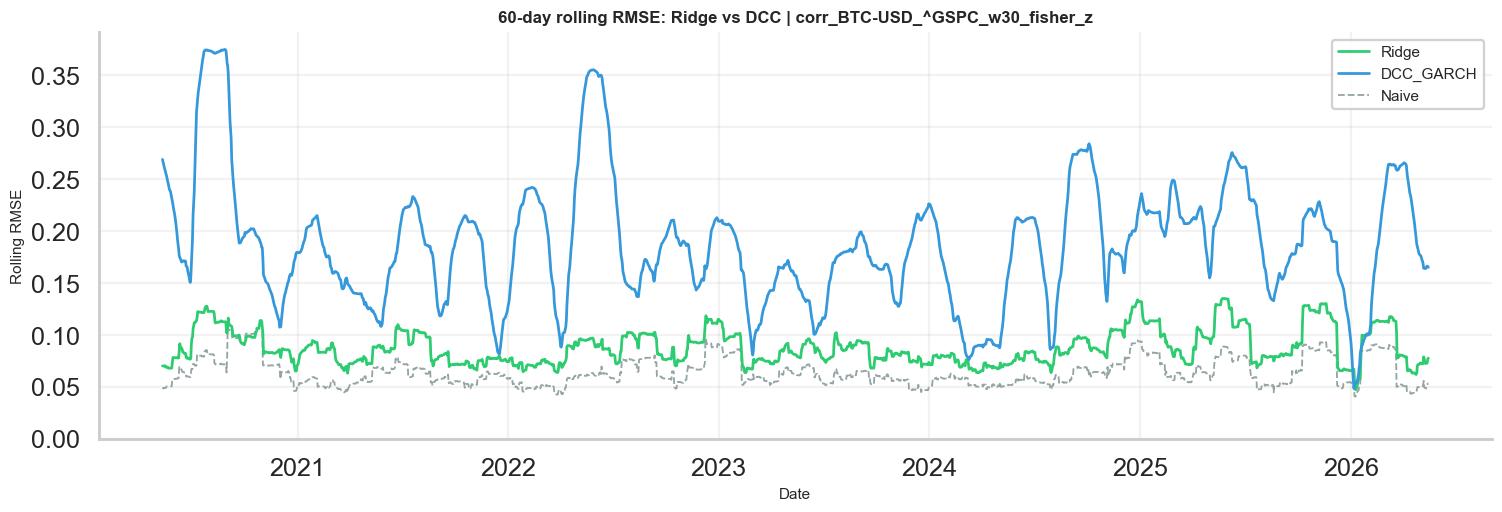

In [5]:
# ── Rolling RMSE over time ────────────────────────────────────────────────────
ROLL_WIN = 60

if ml_col and 'DCC_GARCH' in df.columns:
    e2_ml  = (y - df[ml_col]) ** 2
    e2_dcc = (y - df['DCC_GARCH']) ** 2

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(np.sqrt(e2_ml.rolling(ROLL_WIN).mean()),
            label=ml_label, color='#2ecc71', lw=1.8, zorder=3)
    ax.plot(np.sqrt(e2_dcc.rolling(ROLL_WIN).mean()),
            label='DCC_GARCH', color='#3498db', lw=1.8, zorder=3)
    if 'Naive_Last' in df.columns:
        ax.plot(np.sqrt(((y - df['Naive_Last'])**2).rolling(ROLL_WIN).mean()),
                label='Naive', color='#95a5a6', lw=1.2, ls='--', zorder=2)

    ax.set_title(f'{ROLL_WIN}-day rolling RMSE: {ml_label} vs DCC | {KEY}', fontsize=11)
    ax.set_ylabel('Rolling RMSE', fontsize=10)
    ax.set_xlabel('Date', fontsize=10)
    ax.legend(fontsize=10, framealpha=0.9)
    ax.grid(alpha=0.25)
    ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig(os.path.join(paths.figures, f'rolling_rmse_{KEY}.png'), dpi=150)
    plt.show()
else:
    print(f'{ml_label} or DCC predictions not found.')


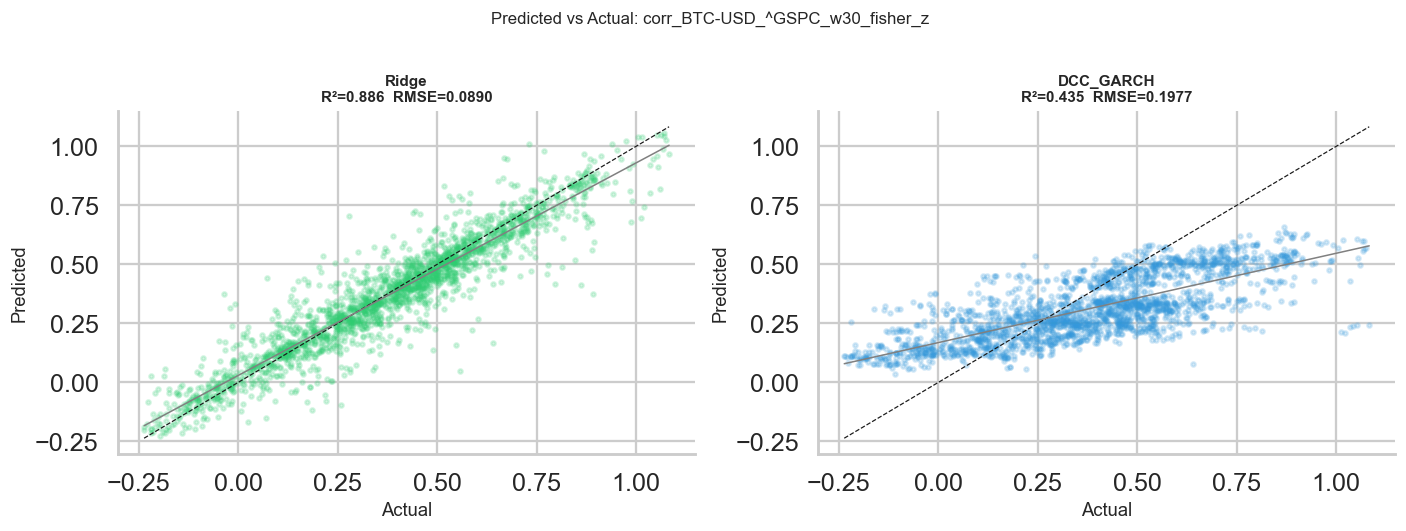

In [6]:
# ── Scatter: predicted vs actual ─────────────────────────────────────────────
if ml_col and 'DCC_GARCH' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, model, color, lbl in zip(
            axes,
            [ml_col, 'DCC_GARCH'],
            ['#2ecc71', '#3498db'],
            [ml_label, 'DCC_GARCH']):
        common = y.dropna().index.intersection(df[model].dropna().index)
        yt = y.loc[common].values
        yp = df.loc[common, model].values
        r2   = r2_score(yt, yp)
        rmse = np.sqrt(mean_squared_error(yt, yp))

        ax.scatter(yt, yp, alpha=0.2, s=8, color=color)
        mn, mx = min(yt.min(), yp.min()), max(yt.max(), yp.max())
        ax.plot([mn, mx], [mn, mx], 'k--', lw=0.8)
        slope, intercept, *_ = stats.linregress(yt, yp)
        xs = np.linspace(mn, mx, 100)
        ax.plot(xs, slope * xs + intercept, color='gray', lw=1)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'{lbl}\nR²={r2:.3f}  RMSE={rmse:.4f}', fontsize=10)

    plt.suptitle(f'Predicted vs Actual: {KEY}', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(paths.figures, f'scatter_{KEY}.png'), dpi=150)
    plt.show()
else:
    print(f'{ml_label} or DCC predictions not found.')


XGB RMSE by pair and window:
window                  14      30      60      90
pair                                              
BTC-USD vs ETH-USD  0.2157  0.1183  0.0614  0.0486
BTC-USD vs GLD      0.2026  0.0998  0.0544  0.0390
BTC-USD vs SLV      0.2068  0.1010  0.0552  0.0401
BTC-USD vs UUP      0.2175  0.1110  0.0624  0.0376
BTC-USD vs ^GSPC    0.2079  0.1004  0.0564  0.0416
BTC-USD vs ^IXIC    0.2008  0.1006  0.0552  0.0410


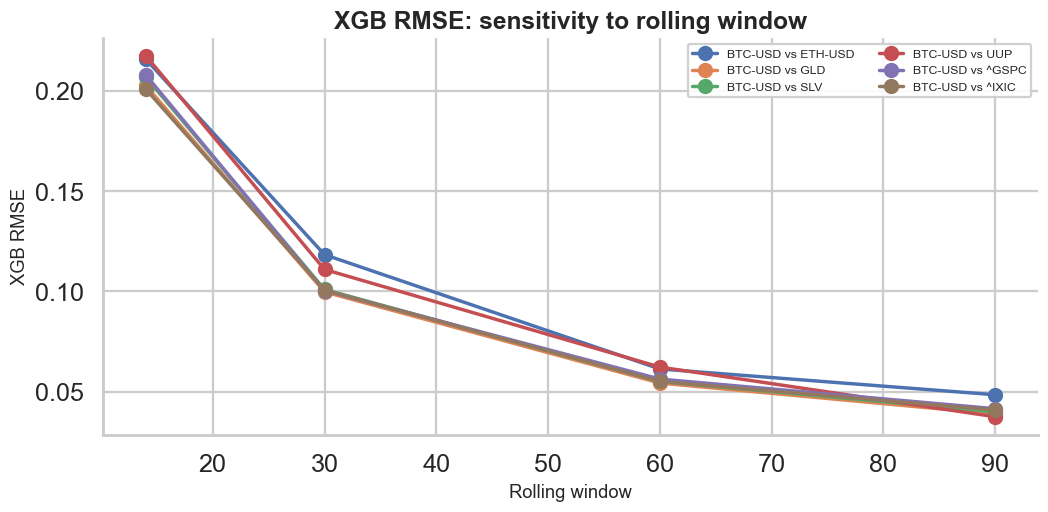

In [7]:
# ── Window sensitivity: XGB RMSE по окнам ────────────────────────
base = cfg['base_asset']
others = cfg['assets']['traditional'] + cfg.get('extra_assets', [])
windows = cfg['rolling_windows']

win_rows = []
for other in others:
    for w in windows:
        key = f'corr_{base}_{other}_w{w}_fisher_z'
        if key not in experiments:
            continue
        df_ = experiments[key]
        y_ = df_['y_true'].dropna()
        xgb_c = 'XGB_GPU' if 'XGB_GPU' in df_.columns else ('XGB_CPU' if 'XGB_CPU' in df_.columns else None)
        if not xgb_c:
            continue
        pred = df_[xgb_c].dropna()
        common = y_.index.intersection(pred.index)
        if len(common) < 50:
            continue
        win_rows.append({'pair': f'{base} vs {other}', 'window': w,
                         'RMSE': np.sqrt(mean_squared_error(y_.loc[common], pred.loc[common])),
                         'R2': r2_score(y_.loc[common], pred.loc[common])})

win_df = pd.DataFrame(win_rows)
if not win_df.empty:
    pivot_win = win_df.pivot_table(index='pair', columns='window', values='RMSE')
    print('XGB RMSE by pair and window:')
    print(pivot_win.round(4).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot_win.T.plot(ax=ax, marker='o')
    ax.set_xlabel('Rolling window')
    ax.set_ylabel('XGB RMSE')
    ax.set_title('XGB RMSE: sensitivity to rolling window')
    ax.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(paths.figures, 'xgb_window_sensitivity.png'), dpi=130)
    plt.show()
else:
    print('Нет данных. Запустите main.py.')


In [8]:
# Final DM summary based on current dm_tests.csv
DM_CSV = os.path.join(paths.results, 'dm_tests.csv')

if os.path.exists(DM_CSV):
    dm = pd.read_csv(DM_CSV)
    ml_label = preferred_xgb_label(dm['model'].unique()) or dm['model'].mode().iloc[0]
    ml_dcc = dm[(dm['model'] == ml_label) & (dm['benchmark'] == 'DCC_GARCH')].copy()

    print(f'{ml_label} vs DCC_GARCH summary:')
    print(f'  Total tests: {len(ml_dcc)}')
    print(f'  ML better (DM > 0): {(ml_dcc["DM_stat"] > 0).sum()}')
    print(f'  Significant (p < 0.05): {(ml_dcc["p_value"] < 0.05).sum()}')
    print(f'  Mean DM stat: {ml_dcc["DM_stat"].mean():.2f}')
    print()

    cols_show = [c for c in ['dependency', 'window', 'DM_stat', 'p_value'] if c in ml_dcc.columns]
    print(ml_dcc[cols_show].to_string(index=False))
else:
    print('Run notebook 04 or the full pipeline first so dm_tests.csv exists.')

print('Deep dive complete.')
print('Interpretation: compare rolling error profiles to show when ML adapts faster than DCC during regime shifts.')


Ridge vs DCC_GARCH summary:
  Total tests: 22
  ML better (DM > 0): 22
  Significant (p < 0.05): 22
  Mean DM stat: 25.30

          dependency  window   DM_stat       p_value
  corr_BTC-USD_^GSPC      90 23.969579 2.225074e-308
  corr_BTC-USD_^GSPC      60 33.256818 2.225074e-308
  corr_BTC-USD_^GSPC      30 25.750760 2.225074e-308
  corr_BTC-USD_^GSPC      14 22.044691 2.225074e-308
  corr_BTC-USD_^IXIC      14 22.236281 2.225074e-308
  corr_BTC-USD_^IXIC      30 24.158261 2.225074e-308
  corr_BTC-USD_^IXIC      90 19.653851 2.225074e-308
  corr_BTC-USD_^IXIC      60 30.196858 2.225074e-308
    corr_BTC-USD_GLD      14 19.678167 2.225074e-308
    corr_BTC-USD_GLD      60 29.131991 2.225074e-308
    corr_BTC-USD_GLD      90 22.855883 2.225074e-308
    corr_BTC-USD_SLV      14 25.122190 2.225074e-308
    corr_BTC-USD_SLV      30 32.379925 2.225074e-308
    corr_BTC-USD_SLV      60 32.287929 2.225074e-308
    corr_BTC-USD_SLV      90 33.512412 2.225074e-308
    corr_BTC-USD_UUP      14 